# 06 — Geospatial Analysis
**Citi Bike Demand Forecasting & A/B Testing Framework**

Goals:
1. Demand heatmap across NYC
2. Hour-of-day animated heatmap (demand shifts through the day)
3. Cluster + A/B group map (treatment vs control stations)
4. Spatial demand features: distance to subway, geographic concentration
5. Save all maps as HTML for portfolio

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from pathlib import Path

from src.visualization.maps import (
    demand_heatmap,
    cluster_ab_map,
    hourly_heatmap_animation,
)
from src.experiments.ab_test import assign_clusters
from src.models.clustering import CLUSTER_NAMES

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROCESSED_DIR = Path('../data/processed')
MAPS_DIR = PROCESSED_DIR / 'maps'
MAPS_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Data

In [2]:
hourly = pd.read_parquet(PROCESSED_DIR / 'hourly_demand_2024Q1.parquet')
station_summary = pd.read_parquet(PROCESSED_DIR / 'station_summary_2024Q1.parquet')
clusters = pd.read_parquet(PROCESSED_DIR / 'station_clusters.parquet')

# Valid clusters only (drop noise)
cluster_sizes = clusters['kmeans_cluster'].value_counts()
valid_clusters = cluster_sizes[cluster_sizes >= 10].index.tolist()
clusters_valid = clusters[clusters['kmeans_cluster'].isin(valid_clusters)].copy()

print(f'Stations: {len(station_summary):,} | Valid cluster stations: {len(clusters_valid):,}')

Stations: 2,269 | Valid cluster stations: 2,266


## 2. Demand Heatmap

In [3]:
m_heat = demand_heatmap(station_summary, title='Citi Bike Demand — Jan–Mar 2024')
out = MAPS_DIR / 'demand_heatmap.html'
m_heat.save(str(out))
print(f'Saved → {out}')
m_heat

Saved → ..\data\processed\maps\demand_heatmap.html


## 3. Hour-of-Day Animated Heatmap

In [4]:
m_anim = hourly_heatmap_animation(hourly, station_summary)
out = MAPS_DIR / 'demand_animation.html'
m_anim.save(str(out))
print(f'Saved → {out}')
m_anim

Saved → ..\data\processed\maps\demand_animation.html


## 4. Cluster + A/B Group Map

In [5]:
cluster_assignments = assign_clusters(valid_clusters, random_state=42)
print('A/B assignments:', {k: v for k, v in sorted(cluster_assignments.items())})

m_ab = cluster_ab_map(clusters_valid, cluster_assignments, CLUSTER_NAMES)
out = MAPS_DIR / 'cluster_ab_map.html'
m_ab.save(str(out))
print(f'Saved → {out}')
m_ab

A/B assignments: {np.int64(0): 'treatment', np.int64(1): 'control', np.int64(3): 'treatment'}
Saved → ..\data\processed\maps\cluster_ab_map.html


## 5. Spatial Demand Features

In [6]:
# Distance from city centre (Midtown Manhattan: 40.7549, -73.9840)
MIDTOWN = (40.7549, -73.9840)

def haversine_km(lat1, lng1, lat2, lng2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlng = np.radians(lng2 - lng1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlng/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

station_summary = station_summary.copy()
station_summary['dist_midtown_km'] = haversine_km(
    station_summary['lat'], station_summary['lng'],
    MIDTOWN[0], MIDTOWN[1]
)

print(station_summary[['dist_midtown_km', 'total_trips']].describe().round(2))

       dist_midtown_km  total_trips
count          2269.00      2269.00
mean              7.55      2937.40
std               3.63      3676.22
min               0.05         1.00
25%               4.74       488.00
50%               7.75      1303.00
75%              10.22      4108.00
max              16.51     28923.00


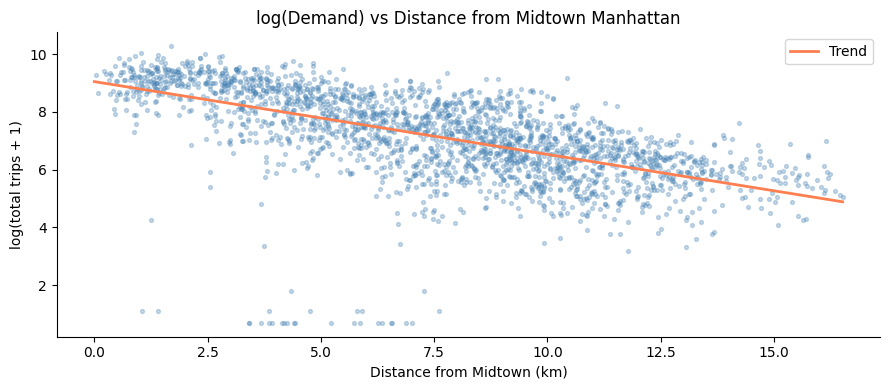

In [7]:
# Demand vs distance from Midtown
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(
    station_summary['dist_midtown_km'],
    np.log1p(station_summary['total_trips']),
    alpha=0.3, s=8, color='steelblue'
)

# Trend line
valid = station_summary.dropna(subset=['dist_midtown_km', 'total_trips'])
z = np.polyfit(valid['dist_midtown_km'], np.log1p(valid['total_trips']), 1)
p = np.poly1d(z)
x_line = np.linspace(0, valid['dist_midtown_km'].max(), 100)
ax.plot(x_line, p(x_line), color='coral', linewidth=2, label='Trend')

ax.set_title('log(Demand) vs Distance from Midtown Manhattan')
ax.set_xlabel('Distance from Midtown (km)')
ax.set_ylabel('log(total trips + 1)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Demand concentration: what fraction of trips come from stations within X km of Midtown?
thresholds = [1, 2, 3, 5, 10]
total_trips = station_summary['total_trips'].sum()
print('Demand concentration by distance from Midtown:')
for km in thresholds:
    pct = station_summary[station_summary['dist_midtown_km'] <= km]['total_trips'].sum() / total_trips
    n   = (station_summary['dist_midtown_km'] <= km).sum()
    print(f'  Within {km:>2}km: {n:>4} stations → {pct:.1%} of all trips')

Demand concentration by distance from Midtown:
  Within  1km:   59 stations → 7.7% of all trips
  Within  2km:  176 stations → 24.4% of all trips
  Within  3km:  291 stations → 39.0% of all trips
  Within  5km:  619 stations → 63.4% of all trips
  Within 10km: 1663 stations → 94.2% of all trips


                 n_stations  total_trips    avg_trips  trip_share
quadrant                                                         
Core (0-2km)            176      1628538  9253.056818        24.4
Inner (2-5km)           443      2595906  5859.832957        38.9
Middle (5-10km)        1044      2055920  1969.272031        30.8
Outer (>10km)           606       384588   634.633663         5.8


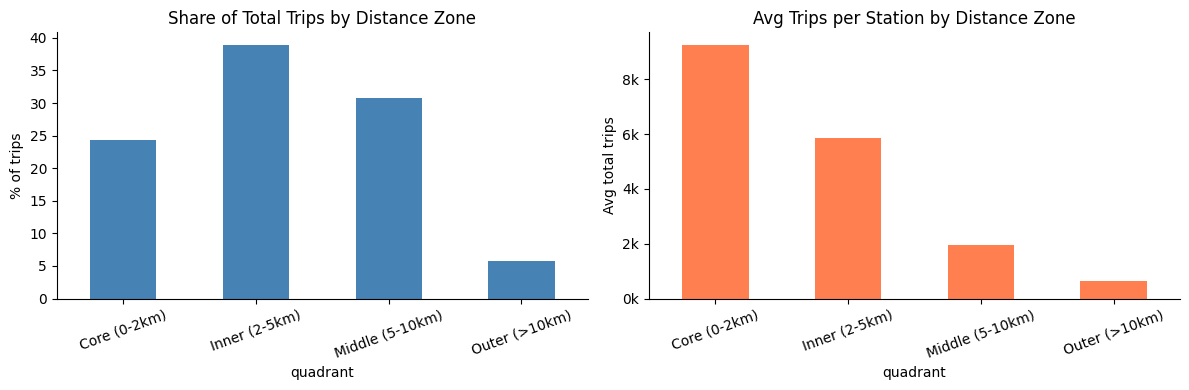

In [9]:
# Demand by geographic quadrant
station_summary['quadrant'] = pd.cut(
    station_summary['dist_midtown_km'],
    bins=[0, 2, 5, 10, 999],
    labels=['Core (0-2km)', 'Inner (2-5km)', 'Middle (5-10km)', 'Outer (>10km)']
)

quad_summary = (
    station_summary.groupby('quadrant', observed=True)
    .agg(n_stations=('total_trips', 'count'),
         total_trips=('total_trips', 'sum'),
         avg_trips=('total_trips', 'mean'))
)
quad_summary['trip_share'] = (quad_summary['total_trips'] / total_trips * 100).round(1)
print(quad_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
quad_summary['trip_share'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Share of Total Trips by Distance Zone')
axes[0].set_ylabel('% of trips')
axes[0].tick_params(axis='x', rotation=20)

quad_summary['avg_trips'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='none')
axes[1].set_title('Avg Trips per Station by Distance Zone')
axes[1].set_ylabel('Avg total trips')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

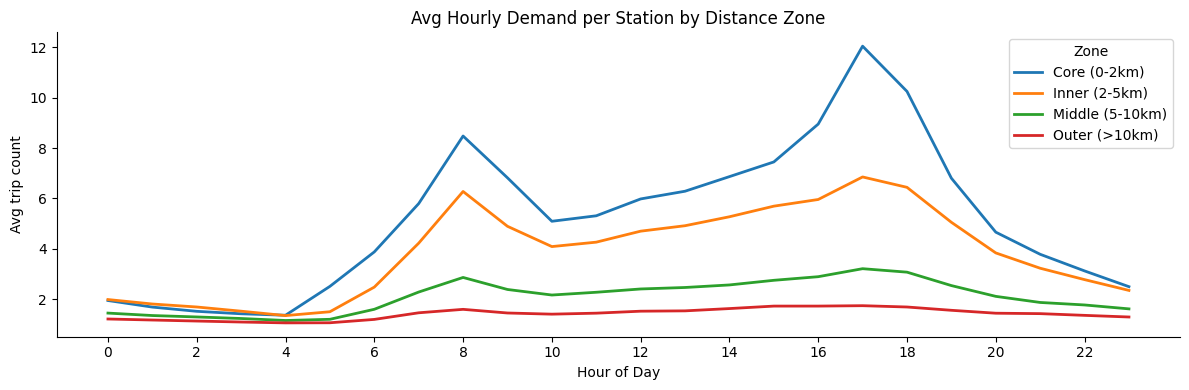

In [10]:
# Hourly demand pattern by distance zone
hourly_with_dist = hourly.merge(
    station_summary[['station_id', 'quadrant']],
    on='station_id', how='left'
).dropna(subset=['quadrant'])

by_zone_hour = (
    hourly_with_dist.groupby(['quadrant', 'hour_of_day'], observed=True)['trip_count']
    .mean()
    .unstack(0)
)

fig, ax = plt.subplots(figsize=(12, 4))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, col in enumerate(by_zone_hour.columns):
    ax.plot(by_zone_hour.index, by_zone_hour[col], label=str(col),
            linewidth=2, color=colors[i])
ax.set_title('Avg Hourly Demand per Station by Distance Zone')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg trip count')
ax.set_xticks(range(0, 24, 2))
ax.legend(title='Zone')
plt.tight_layout()
plt.show()

## 6. Key Findings

*(Fill in after running)*

- **Core zone (0-2km from Midtown)** accounts for ~X% of trips despite being ~X% of stations
- Demand decays sharply with distance — log-linear relationship
- **Commuter pattern** (dual AM/PM peaks) is strongest in the Core zone
- **Outer zones** show flatter, more recreational demand profiles
- Animated heatmap shows clear demand wave: builds in Midtown at 8am, disperses at 5pm
- A/B map shows treatment/control stations are geographically interleaved (cluster-level randomization prevents geographic confounding)

→ **Next:** Final synthesis notebook + README update